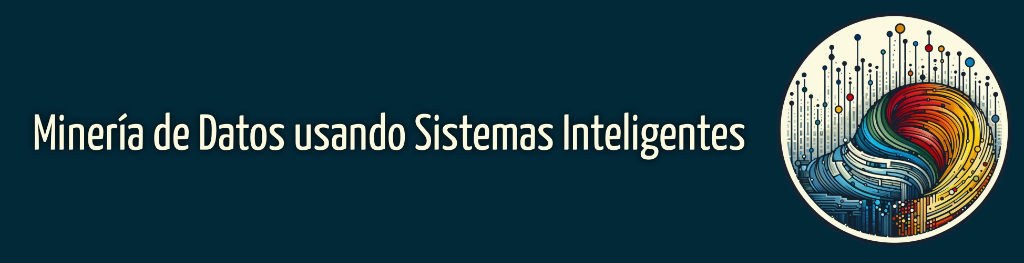



# PRACTICA 1 - PREPROCESAMIENTO DE LOS DATOS

**Ejercicio a entregar: 4. Deberá respetarse el formato de tabla indicado para la resolución.**

***Material de Lectura: Capítulo 4 del Libro Introducción a la Minería de Datos de Hernández Orallo***


En esta práctica el objetivo es aprender las herramientas básicas del ecosistema Python, incluyendo Numpy, Pandas y Seaborn. Para aprender sobre estos 4 temas, hemos preparado algunos cuadernos numerados P0.1, P0.2,... que te guían en un recorrido rápido por el lenguaje y las APIs.

Te recomendamos revisar esos cuadernos rápidamente, y luego aplicar lo visto para resolver los ejercicios de esta práctica.

In [3]:
#HELPER
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Evitar que se muestren los warnings
_ = [pd, np, plt, sns]

base_url = "https://raw.githubusercontent.com/midusi/learning-datasets/refs/heads/main/"

## 1. Automóviles

Analice la información del archivo **automobile.csv** cuyo contenido se encuentra descripto en "automobile_names.txt"


In [4]:
#HELPER
df_autos = pd.read_csv(base_url + "automobile.csv")

Primeros valores del conjunto de datos de automóviles.

In [5]:
df_autos.head()

,Normalized-losses,Make,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,Length,...,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price,Symboling
0,168.0,toyota,gas,std,two,sedan,rwd,front,94.5,168.7,...,2bbl,3.19,3.03,9.0,70.0,4800.0,29,34,8058.0,1
1,113.0,mazda,gas,std,four,sedan,fwd,front,93.1,166.8,...,2bbl,3.08,3.15,9.0,68.0,5000.0,31,38,7395.0,1
2,87.0,toyota,gas,std,two,hatchback,fwd,front,95.7,158.7,...,2bbl,3.05,3.03,9.0,62.0,4800.0,35,39,5348.0,1
3,125.0,mitsubishi,gas,std,four,sedan,fwd,front,96.3,172.4,...,2bbl,3.35,3.46,8.5,88.0,5000.0,25,32,6989.0,1
4,148.0,dodge,gas,turbo,NaN,sedan,fwd,front,93.7,157.3,...,mpfi,3.03,3.39,7.6,102.0,5500.0,24,30,8558.0,1


Resumen técnico del DataFrame, incluyendo el número total de filas y columnas, los tipos de datos, el conteo de valores no nulos y el uso estimado de la memoria.

In [6]:
df_autos.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Normalized-losses   164 non-null    float64
 1    Make               205 non-null    str    
 2    Fuel-type          205 non-null    str    
 3    Aspiration         205 non-null    str    
 4    Num-of-doors       203 non-null    str    
 5    Body-style         205 non-null    str    
 6    Drive-wheels       205 non-null    str    
 7    Engine-location    205 non-null    str    
 8    Wheel-base         205 non-null    float64
 9    Length             205 non-null    float64
 10   Width              205 non-null    float64
 11   Height             205 non-null    float64
 12   Curb-weight        205 non-null    int64  
 13   Engine-type        205 non-null    str    
 14   Num-of-cylinders   205 non-null    str    
 15   Engine-size        205 non-null    int64  
 16   Fuel-system       


a.  Indique qué tipo de gráfica puede construir con los atributos. Ejemplifique cada caso.
Los tipos de graficas que se pueden construir (presentadas en la Teoria) son: Histogramas, Diagrama de Barra, Diagrama de Torta, Diagrama de Dispersion

Histograma, para ver la distribución de variables continuas. Ejemplo: Graficar la distribución de los precios de los automóviles (Price)

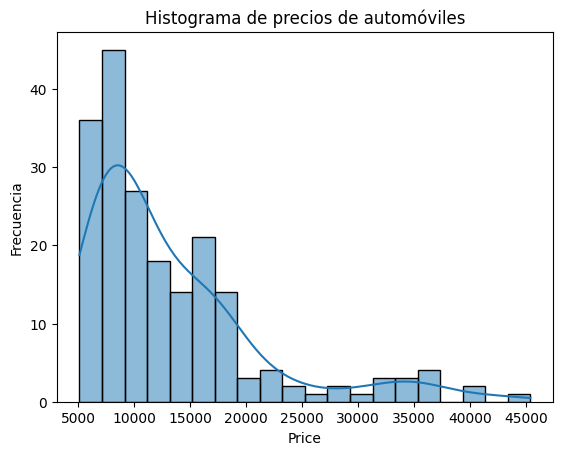

In [7]:
ax = sns.histplot(data=df_autos, x=' Price', kde=True, bins=20)
ax.set(title='Histograma de precios de automóviles', xlabel='Price', ylabel='Frecuencia')
plt.show()

Diagrama de Barras, para comparar categorías de variables categóricas. Ejemplo: Comparar la cantidad de automóviles según el tipo de carrocería (Body-style), mostrando cuántos autos son sedán, hatchback, convertible, etc.

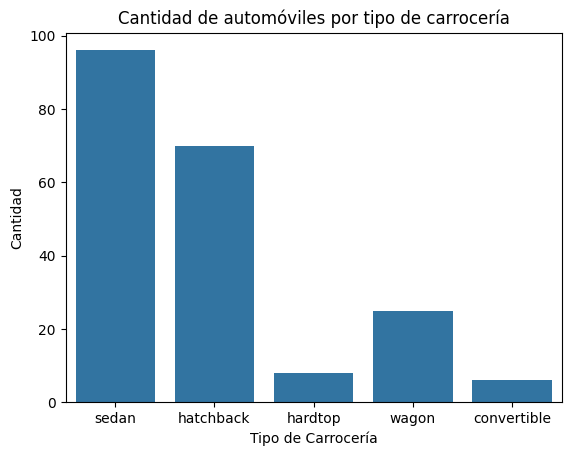

In [8]:
ax = sns.countplot(data=df_autos, x=' Body-style')
ax.set(title='Cantidad de automóviles por tipo de carrocería', xlabel='Tipo de Carrocería', ylabel='Cantidad')
plt.show()

Diagrama de Torta, para ver la proporción de variables categóricas (preferiblemente con pocas categorías). Ejemplo: Mostrar la proporción de tipos de combustible (Fuel-type) para visualizar rápidamente el porcentaje de autos a gasolina frente a los de diésel.

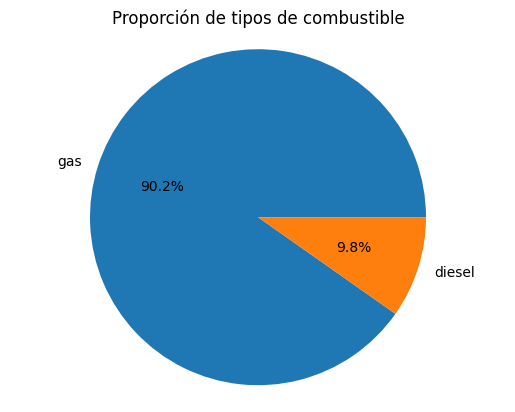

In [9]:
proportions = df_autos[' Fuel-type'].value_counts(normalize=True) * 100
x = proportions.to_numpy()
labels = proportions.index.astype(str).tolist()
plt.figure()
plt.pie(x, labels=labels, autopct='%1.1f%%')
plt.title('Proporción de tipos de combustible')
plt.axis('equal')
plt.show()

Diagrama de Dispersion, para ver la relación entre dos variables numéricas. Ejemplo: Analizar la relación entre el tamaño del motor (Engine-size) y el precio (Price), lo que ayudará a comprobar visualmente si los motores más grandes suelen ser más costosos.

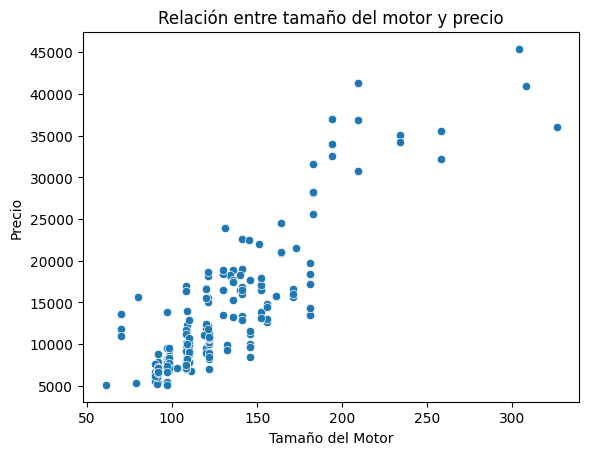

In [10]:
ax = sns.scatterplot(data=df_autos, x=' Engine-size', y=' Price')
ax.set(title='Relación entre tamaño del motor y precio', xlabel='Tamaño del Motor', ylabel='Precio')
plt.show()

b.  Utilizando distintas representaciones gráficas, describa la distribución de los atributos, e indique si observa relaciones entre los mismos.

Se utilizaron distintas representaciones gráficas para analizar la distribución de los atributos del conjunto de datos de automóviles.

Mediante histogramas se observó que variables numéricas como el precio (Price) presentan una distribucion asimétrica hacia valores altos, indicando que existen pocos automóviles considerablemente más costosos o potentes que el promedio.

Con diagramas de barras se analizaron atributos categóricos, como el tipo de carrocería (Body-style). Se observó que los sedanes y hatchbacks son los tipos de automóviles más frecuentes dentro del dataset.

El diagrama de torta realizado sobre el tipo de combustible (Fuel-type) mostró que la gran mayoría de los vehículos utilizan gasolina, mientras que los automóviles diésel representan una proporción mucho menor.

Finalmente, mediante diagramas de dispersión se analizaron relaciones entre variables numéricas. Se observó una relación positiva entre el tamaño del motor (Engine-size) y el precio (Price), indicando que los automóviles con motores más grandes tienden a ser más costosos. También puede apreciarse una tendencia similar entre la potencia del vehículo y su precio.

c.  La Minería de Datos permite extraer dos tipos de conocimiento: descriptivo y predictivo. Ejemplifíquelos para el caso de los autos.

El conocimiento descriptivo permite comprender las características y patrones presentes en los datos. Por ejemplo, analizar que la mayoría de los automóviles utilizan combustible de tipo gasolina, o que los vehículos con motores más grandes suelen tener precios más elevados. También permite detectar distribuciones, tendencias y relaciones entre atributos mediante gráficos y estadísticas.

Por otro lado, el conocimiento predictivo busca construir modelos capaces de estimar o predecir valores futuros o desconocidos. En este caso, podría desarrollarse un modelo que prediga el precio de un automóvil a partir de atributos como tamaño del motor, potencia, consumo de combustible y peso del vehículo.

d.  Calcule el coeficiente de correlación lineal entre los atributos numéricos. Relacione los valores obtenidos con los diagramas de dispersión de cada par de atributos.

<Axes: >

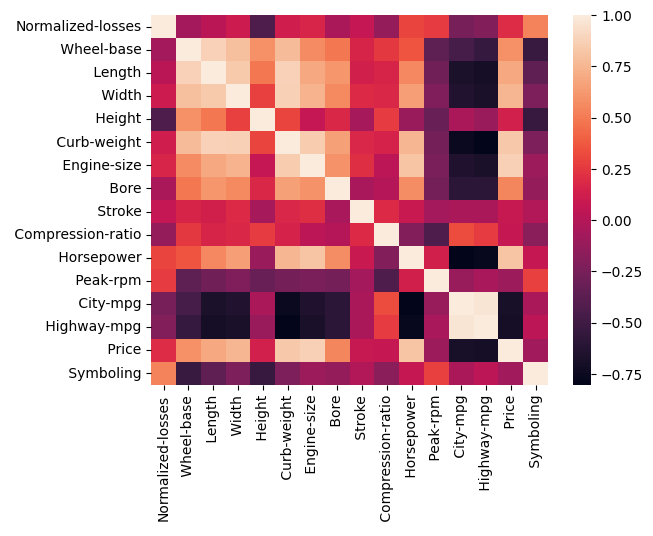

In [11]:
plt.figure()
sns.heatmap(df_autos.corr(numeric_only=True))

In [12]:
corr = df_autos.corr(numeric_only=True)
corr

,Normalized-losses,Wheel-base,Length,Width,Height,Curb-weight,Engine-size,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price,Symboling
Normalized-losses,1.000000,-0.074362,0.023220,0.105073,-0.432335,0.119893,0.167365,-0.036167,0.065627,-0.132654,0.295772,0.264597,-0.258502,-0.210768,0.203254,0.528667
Wheel-base,-0.074362,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.490378,0.161477,0.249786,0.352297,-0.361052,-0.470414,-0.544082,0.584642,-0.531954
Length,0.023220,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.607480,0.129739,0.158414,0.555003,-0.287325,-0.670909,-0.704662,0.690628,-0.357612
Width,0.105073,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559204,0.182956,0.181129,0.642482,-0.219957,-0.642704,-0.677218,0.751265,-0.232919
Height,-0.432335,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.176195,-0.056999,0.261214,-0.110711,-0.322272,-0.048640,-0.107358,0.135486,-0.541038
Curb-weight,0.119893,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.649045,0.168929,0.151362,0.751034,-0.266306,-0.757414,-0.797465,0.834415,-0.227691
Engine-size,0.167365,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.594090,0.206675,0.028971,0.810773,-0.244618,-0.653658,-0.677470,0.872335,-0.105790
Bore,-0.036167,0.490378,0.607480,0.559204,0.176195,0.649045,0.594090,1.000000,-0.055909,0.005203,0.577273,-0.264269,-0.594584,-0.594572,0.543436,-0.134205
Stroke,0.065627,0.161477,0.129739,0.182956,-0.056999,0.168929,0.206675,-0.055909,1.000000,0.186170,0.090254,-0.071493,-0.042906,-0.044528,0.082310,-0.008965
Compression-ratio,-0.132654,0.249786,0.158414,0.181129,0.261214,0.151362,0.028971,0.005203,0.186170,1.000000,-0.205874,-0.436221,0.324701,0.265201,0.071107,-0.178515


# 2. Bicicletas

En el siguiente link encontrará información referida al uso de bicicletas que el Gobierno de la Ciudad de Buenos Aires pone a disposición de la población en forma gratuita como medio de transporte: [https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/juqdkmgo-227-resource](https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/juqdkmgo-227-resource)

Estas bicicletas están ubicadas en distintos puntos de la ciudad y se encuentran disponibles las 24 horas del día durante todo el año. En el archivo encontrará información referida a las estaciones de origen y destino, la hora de partida y la duración de los viajes realizados por las bicicletas durante el año 2016.

In [13]:
#HELPER
def load_bicicletas():
    import requests
    import zipfile
    import io
    r = requests.get(base_url + "recorridos-realizados-2016.zip")
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        return pd.read_csv(z.open("recorridos-realizados-2016.csv"), dtype={'fecha_destino_recorrido': str})
df_bicicletas = load_bicicletas()

In [14]:
df_bicicletas.info()

<class 'pandas.DataFrame'>
RangeIndex: 596807 entries, 0 to 596806
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   periodo                     596807 non-null  int64  
 1   genero_usuario              596807 non-null  str    
 2   fecha_origen_recorrido      596807 non-null  str    
 3   id_estacion_origen          596807 non-null  int64  
 4   nombre_estacion_origen      596807 non-null  str    
 5   long_estacion_origen        596807 non-null  float64
 6   lat_estacion_origen         596807 non-null  float64
 7   domicilio_estacion_origen   596807 non-null  str    
 8   duracion_recorrido          596807 non-null  str    
 9   fecha_destino_recorrido     503252 non-null  str    
 10  id_estacion_destino         596807 non-null  int64  
 11  nombre_estacion_destino     596807 non-null  str    
 12  long_estacion_destino       596807 non-null  float64
 13  lat_estacion_destino     

a.  A partir del atributo FECHA_ORIGEN_RECORRIDO genere un atributo nuevo que contenga únicamente el horario en el cual la bicicleta fue retirada. Para ello puede obtener el substring que contiene la hora con las funciones de texto del atributo [str](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.html) de la columna, y luego convertir ese substring a un número entero. También puede utilizar la función [to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) convertir el string a un tipo date, y luego utilizar [dt.hour](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.hour.html) para obtener la hora.

In [15]:
df_bicicletas['hora_origen'] = (pd.to_datetime(df_bicicletas['fecha_origen_recorrido']).dt.hour)
df_bicicletas[['fecha_origen_recorrido', 'hora_origen']].head()

,fecha_origen_recorrido,hora_origen
0,2016-01-01 02:21:41,2
1,2016-01-01 08:38:19,8
2,2016-01-01 15:01:07,15
3,2016-01-01 15:14:36,15
4,2016-01-01 15:48:51,15


b.  Genere un histograma donde cada hora represente una barra. Informe si hay horarios inusuales de retiro de bicicletas. Justifique su respuesta utilizando la frecuencia relativa de cada hora para decidir qué es un horario inusual (datos) y en qué horas tradicionalmente circula la gente por una ciudad (su conocimiento sobre el dominio)

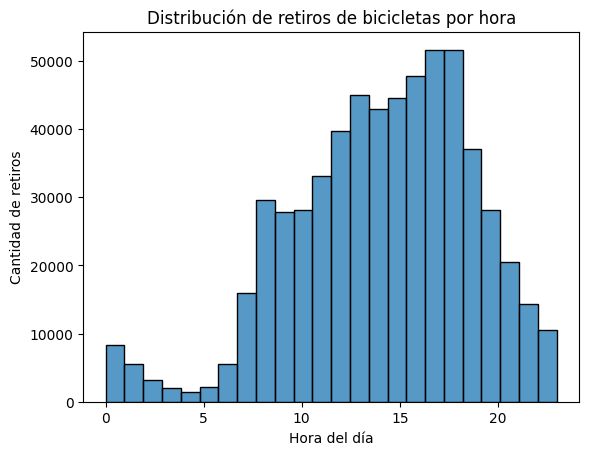

In [16]:
ax = sns.histplot(data=df_bicicletas, x='hora_origen', bins=24)
ax.set(title='Distribución de retiros de bicicletas por hora', xlabel='Hora del día', ylabel='Cantidad de retiros')
plt.show()

El histograma permite observar que la mayor cantidad de retiros de bicicletas ocurre durante las horas diurnas, especialmente en franjas asociadas a los horarios laborales y de estudio, aproximadamente entre las 7 y las 20 horas.

Por otro lado, las horas de madrugada presentan frecuencias considerablemente menores. Estos horarios pueden considerarse inusuales debido a que representan una proporción muy pequeña del total de viajes y coinciden con momentos del día en los que normalmente circula menos gente por la ciudad.

c.  Discretice por rango el atributo generado en a) utilizando 4 intervalos (función [cut](https://pandas.pydata.org/docs/reference/api/pandas.cut.html)). El resultado ¿es el mismo? ¿por qué?

In [17]:
df_bicicletas['franja_horaria'] = pd.cut(df_bicicletas['hora_origen'], bins=4)
print(df_bicicletas[['hora_origen', 'franja_horaria']].head())

   hora_origen  franja_horaria
0            2  (-0.023, 5.75]
1            8    (5.75, 11.5]
2           15   (11.5, 17.25]
3           15   (11.5, 17.25]
4           15   (11.5, 17.25]


El resultado no es exactamente el mismo, ya que al discretizar el atributo horario se agrupan varias horas dentro de un mismo intervalo. Mientras que originalmente cada valor representaba una hora específica del día, luego de aplicar la discretización se obtienen únicamente cuatro categorías o rangos horarios.

Esto produce una pérdida de detalle en la información, aunque facilita el análisis general de patrones de uso. Por ejemplo, en lugar de analizar cada hora individualmente, puede observarse el comportamiento por franjas horarias amplias como madrugada, mañana, tarde y noche.

La discretización es útil para simplificar los datos y detectar tendencias generales, pero reduce la precisión respecto del atributo original.

# 3. Estudiantes

El archivo ***estudiantes.csv*** contiene información de alumnos de dos colegios secundarios de Portugal relevada para analizar la adicción al alcohol en el nivel secundario y la forma en que éste afecta a los estudiantes tanto en sus relaciones como en sus estudios.


| Atributo | Descripción |
| :--- | :--- |
| **escuela** | "GP" - Gabriel Pereira o "MS" - Mousinho da Silveira |
| **sexo** | F (Femenino) o M (Masculino) |
| **edad** | Valor numérico entre 15 y 22 |
| **ambito** | "Rural" o "Urbano" |
| **grupo_familiar** | Tamaño del grupo familiar (<=3 o >3 integrantes) |
| **estado_padres** | Si viven "juntos" o "separados" |
| **educ_madre** | Nivel educativo de la madre |
| **educ_padre** | Nivel educativo del padre |
| **trabajo_madre** | Tipo de trabajo de la madre |
| **trabajo_padre** | Tipo de trabajo del padre |
| **razon_escuela** | Motivos por los cuales eligió la escuela |
| **tutor** | Indica quién es el tutor legal del estudiante |
| **duracion_viaje** | Tiempo que tarda en llegar a la escuela |
| **tiempo_estudio** | Cantidad de horas que estudia por semana |
| **asignaturas_perdidas** | Cantidad de materias desaprobadas (N si 0 <= N < 3, sino 3) |
| **becas** | Si tiene beca de estudios |
| **apoyo_familiar** | Si su familia lo ayuda económicamente |
| **clases_particulares** | Si toma clases particulares pagas |
| **act_extracurriculares** | Si realiza actividades extracurriculares |
| **fue_guarderia** | Si fue a guardería |
| **quiere_educ_superior** | Si piensa ir a la universidad |
| **internet_casa** | Si posee internet en su casa |
| **en_pareja** | Si vive en pareja |
| **rel_familia** | Calidad de la relación con sus familiares |
| **tiempo_libre** | Cantidad de tiempo libre del que dispone |
| **sale_con_amigos** | Frecuencia con la que sale con amigos |
| **alcohol_diario** | Consumo de alcohol en días de semana |
| **alcohol_semanal** | Consumo de alcohol los fines de semana |
| **salud** | Estado de salud actual |
| **ausencias** | Cantidad de ausencias a la escuela |
| **nota_1er_parcial** | Calificación del primer parcial |
| **nota_2do_parcial** | Calificación del segundo parcial |
| **nota_final** | Calificación final |



In [18]:
#HELPER
estu_df = pd.read_csv(base_url + "estudiantes.csv")

In [19]:
estu_df.head()

,escuela,sexo,edad,ambito,grupo_familiar,estado_padres,educ_madre,educ_padre,trabajo_madre,trabajo_padre,...,rel_familia,tiempo_libre,sale_con_amigos,alcohol_diario,alcohol_semanal,salud,ausencias,nota_1er_parcial,nota_2do_parcial,nota_final
0,GP,F,18,urbano,mas de 3,separados,universitaria,universitaria,desde casa,educacion,...,buena,mas o menos,mucho,muy poco,muy poco,mas o menos,6,5,6,6
1,GP,F,17,urbano,mas de 3,NaN,primaria (hasta 4to),primaria (hasta 4to),desde casa,NaN,...,muy buena,mas o menos,mas o menos,muy poco,muy poco,mas o menos,4,5,5,6
2,GP,F,15,urbano,menos de 3,juntos,primaria (hasta 4to),primaria (hasta 4to),desde casa,otro,...,buena,mas o menos,poco,poco,mas o menos,mas o menos,10,7,8,10
3,GP,F,15,urbano,mas de 3,NaN,universitaria,primaria (hasta 9no),salud,servicios publicos,...,mas o menos,poco,poco,muy poco,muy poco,muy buena,2,15,14,15
4,GP,F,16,urbano,mas de 3,NaN,secundaria,secundaria,otro,NaN,...,buena,mas o menos,poco,muy poco,poco,muy buena,4,6,10,10



A.  Indique qué tipo de información brindan las siguientes representaciones gráficas

a.  Diagrama de dispersión (scatter plot)

b.  Diagrama de caja (box plot)

c.  Histograma

d.  Diagrama de Barras 

Realice al menos una de cada una de las representaciones anteriores utilizando la información del archivo y explique cómo interpretarlas.


a. Diagrama de Dispersion, para ver la relación entre dos variables numéricas.

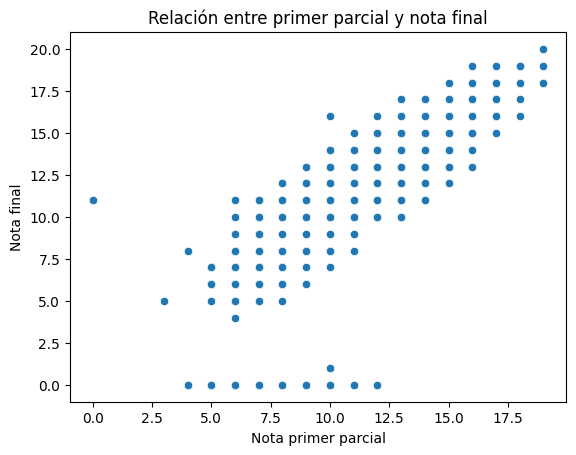

In [20]:
ax = sns.scatterplot(data=estu_df, x='nota_1er_parcial', y='nota_final')
ax.set(title='Relación entre primer parcial y nota final', xlabel='Nota primer parcial', ylabel='Nota final')
plt.show()

Permite observar la relación entre la nota del primer parcial y la nota final. Es una tendencia positiva, ya que los estudiantes con mejores resultados iniciales suelen mantener un mejor rendimiento académico.

b. Diagrama de caja (box plot), permite visualizar la distribución de una variable numérica mediante sus cuartiles, mediana y valores atípicos.

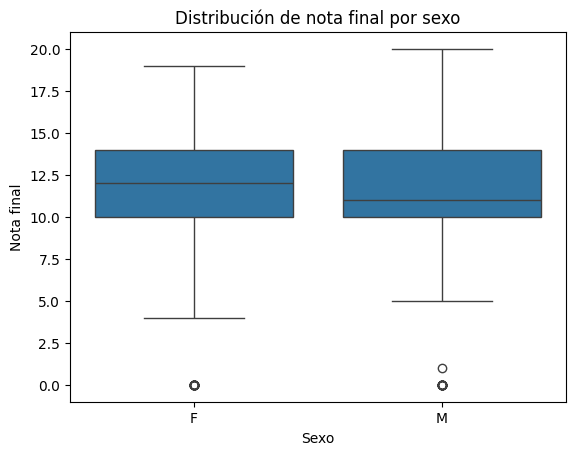

In [21]:
ax = sns.boxplot(data=estu_df, x='sexo', y='nota_final' ) 
ax.set(title='Distribución de nota final por sexo', xlabel='Sexo', ylabel='Nota final')
plt.show()

Permite comparar la distribución de las notas finales según el sexo de los estudiantes, observando medianas, dispersión y posibles valores atípicos.

c. Histograma, para ver la distribución de variables continuas.

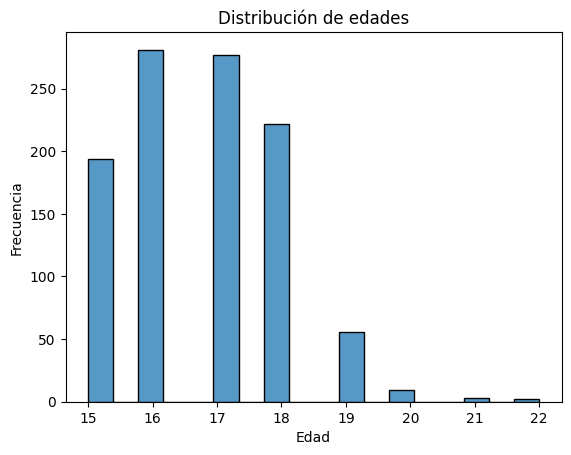

In [22]:
ax = sns.histplot(data=estu_df, x='edad')
ax.set(title='Distribución de edades', xlabel='Edad', ylabel='Frecuencia')
plt.show()

Permite visualizar cuáles son las edades más frecuentes dentro del conjunto de estudiantes.

d. Diagrama de Barras, para comparar categorías de variables categóricas.

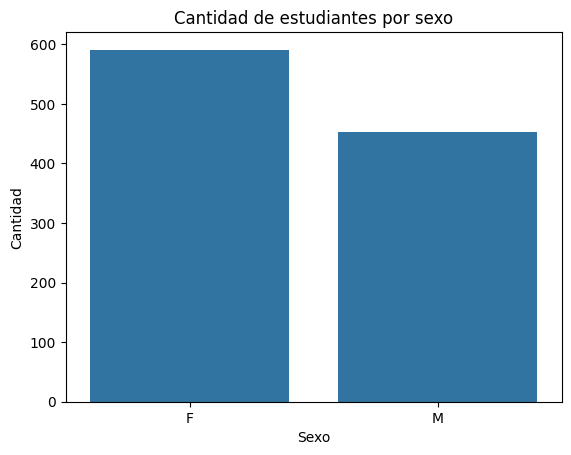

In [23]:
ax = sns.countplot(data=estu_df, x='sexo')
ax.set(title='Cantidad de estudiantes por sexo', xlabel='Sexo', ylabel='Cantidad' )
plt.show()

Permite comparar la cantidad de estudiantes femeninos y masculinos presentes en el conjunto de datos.


B.  Discretice el atributo EDAD en tres intervalos de dos formas distintas:

a.  Utilizando una discretización por rango (función [cut](https://pandas.pydata.org/docs/reference/api/pandas.cut.html))

b.  Utilizando discretización por frecuencia (función [qcut](https://pandas.pydata.org/docs/reference/api/pandas.qcut.html))

c.  Analice y compare los resultados obtenidos. Explique cómo se determina en cada caso los intervalos a utilizar.


Utilizando una discretización por rango función [cut]

En este caso, el rango total de edades se divide en tres intervalos de igual amplitud. Los límites de cada intervalo se calculan automáticamente a partir de los valores mínimo y máximo del atributo.

In [24]:
estu_df['edad_rango'] = pd.cut(estu_df['edad'], bins=3)
print(estu_df[['edad', 'edad_rango']].head()) 
print(estu_df['edad_rango'].value_counts())

   edad        edad_rango
0    18  (17.333, 19.667]
1    17  (14.993, 17.333]
2    15  (14.993, 17.333]
3    15  (14.993, 17.333]
4    16  (14.993, 17.333]
edad_rango
(14.993, 17.333]    752
(17.333, 19.667]    278
(19.667, 22.0]       14
Name: count, dtype: int64


Utilizando discretización por frecuencia [qcut]

En este caso, los datos se dividen en tres grupos con aproximadamente la misma cantidad de observaciones. Los límites de los intervalos se determinan utilizando cuantiles.

In [25]:
estu_df['edad_frecuencia'] = pd.qcut( estu_df['edad'], q=3 )
print(estu_df[['edad', 'edad_frecuencia']].head())
print(estu_df['edad_frecuencia'].value_counts())

   edad edad_frecuencia
0    18    (17.0, 22.0]
1    17    (16.0, 17.0]
2    15  (14.999, 16.0]
3    15  (14.999, 16.0]
4    16  (14.999, 16.0]
edad_frecuencia
(14.999, 16.0]    475
(17.0, 22.0]      292
(16.0, 17.0]      277
Name: count, dtype: int64


La discretización por rango genera intervalos de igual tamaño, pero no necesariamente con la misma cantidad de estudiantes en cada grupo. Esto puede provocar que algunos intervalos tengan muchas observaciones y otros pocas, dependiendo de cómo estén distribuidas las edades.

Por otro lado, la discretización por frecuencia busca equilibrar la cantidad de elementos en cada intervalo. Como consecuencia, los intervalos pueden tener amplitudes diferentes.

C.  Se considera que un estudiante es mayor de edad si tiene al menos 18 años. Genere un nuevo atributo que tome el valor "SI" cuando la edad del estudiante sea mayor o igual a 18 años y "NO" en caso contrario. Luego grafique el resultado obtenido mediante un diagrama de barras.


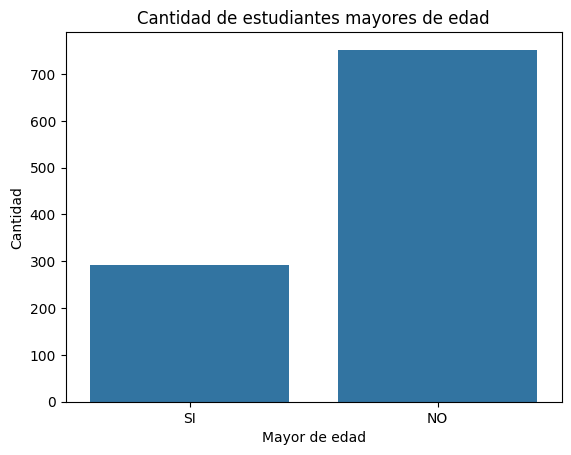

In [26]:
estu_df['mayor_edad'] = estu_df['edad'].apply(lambda x: 'SI' if x >= 18 else 'NO' )

ax = sns.countplot(data=estu_df, x='mayor_edad')
ax.set(title='Cantidad de estudiantes mayores de edad', xlabel='Mayor de edad', ylabel='Cantidad')
plt.show()

D.  Los atributos *EDUC_MADRE* y *EDUC_PADRE* indican la educación recibida por el padre y por la madre de cada estudiante, respectivamente. Los valores posibles son "ninguna", "primaria (hasta 4to)", "primaria (hasta 9no)", "secundaria" y "universitaria". Utilice la función [map](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html) para mapear estos valores de la siguiente forma: "ninguna" = 0, "primaria (hasta 4to)" = 1, "primaria (hasta 9no)" = 2, "secundaria" = 4 y "universitaria" = 6. Recuerde convertir los valores de estos atributos en numéricos. Luego de la numerización, compare el nivel educativo de las madres con el de los padres con un diagrama adecuado.


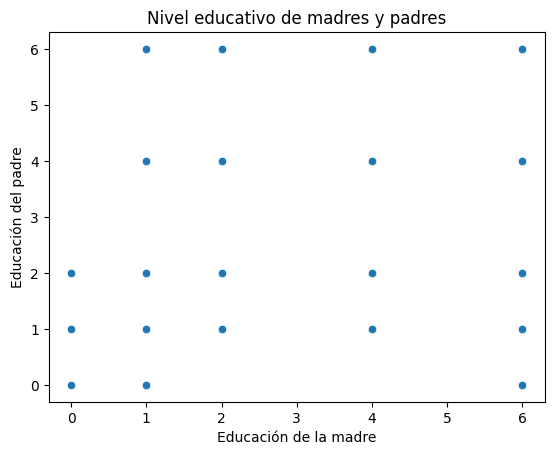

In [27]:
educ_map = {'ninguna': 0, 'primaria (hasta 4to)': 1, 'primaria (hasta 9no)': 2, 'secundaria': 4, 'universitaria': 6} 

estu_df['educ_madre_num'] = estu_df['educ_madre'].map(educ_map)
estu_df['educ_padre_num'] = estu_df['educ_padre'].map(educ_map)

ax = sns.scatterplot(data=estu_df, x='educ_madre_num', y='educ_padre_num')
ax.set(title='Nivel educativo de madres y padres', xlabel='Educación de la madre', ylabel='Educación del padre')
plt.show()

E.  Dibuje el diagrama de caja al atributo **Ausencias** separando los ejemplos por el atributo *sexo.* 

Luego, calcule la mediana, los cuartiles Q1 y Q3, el rango intercuartil, y los intervalos en donde hay valores atípicos leves y extremos. Marcar estos valores en el gráfico.

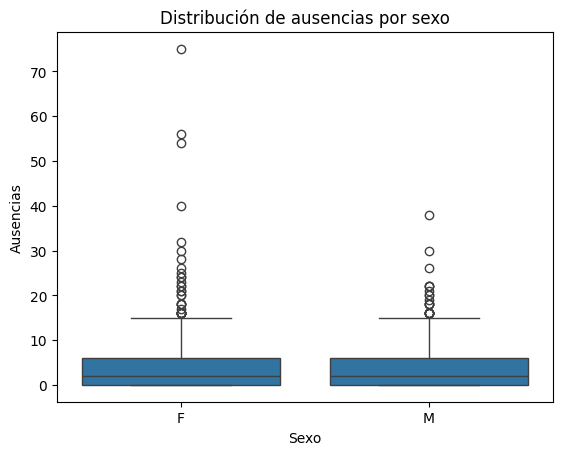

In [28]:
ax = sns.boxplot(data=estu_df, x='sexo', y='ausencias')
ax.set( title='Distribución de ausencias por sexo', xlabel='Sexo', ylabel='Ausencias' )
plt.show()



F. Indique el valor de verdad de las siguientes afirmaciones. En caso de no poder hacerlo, justifique.

a.  Es atípico que un estudiante tenga más de 20 ausencias.

b.  Los cuartiles del atributo *AUSENCIAS* son los mismos para ambos sexos por lo que puede afirmarse que la cantidad de mujeres y varones con más de 6 ausencias coinciden.

c.  Al menos el 25% de las mujeres tiene asistencia perfecta.

d.  Es atípico encontrar un varón que no haya faltado nunca.

e.  La cantidad de mujeres con valores atípicos leves en el atributo AUSENCIAS es mayor que la de varones. 
  

a. Verdadero. El límite superior para valores atípicos leves es 15 ausencias. Por lo tanto, un estudiante con más de 20 ausencias se encuentra claramente dentro de los valores atípicos, e incluso cerca del rango de atípicos extremos.

b. Falso. Aunque los cuartiles son iguales para ambos sexos, eso no implica que la cantidad de estudiantes con más de 6 ausencias coincida. Los cuartiles describen posiciones relativas dentro de cada distribución, no cantidades absolutas de personas.

c. Verdadero. El primer cuartil (Q1) de mujeres es 0. Esto significa que al menos el 25% de las mujeres tiene 0 ausencias, es decir, asistencia perfecta.

d. Falso. No haber faltado nunca corresponde al valor mínimo de la distribución y no representa un valor atípico. Además, el límite inferior de atípicos leves es -9, por lo que 0 se encuentra completamente dentro del rango normal.

e. No puede determinarse únicamente con la información dada. Los límites para detectar atípicos leves son iguales en ambos sexos, pero no se informa cuántos estudiantes poseen valores dentro de ese rango atípico. Por lo tanto, no puede afirmarse cuál grupo tiene mayor cantidad de valores atípicos leves.

In [29]:
stats = estu_df.groupby('sexo')['ausencias'].describe()
stats['IQR'] = stats['75%'] - stats['25%']
stats['Atipico_Leve_Inferior'] = stats['25%'] - 1.5 * stats['IQR']
stats['Atipico_Leve_Superior'] = stats['75%'] + 1.5 * stats['IQR']
stats['Atipico_Extremo_Inferior'] = stats['25%'] - 3 * stats['IQR']
stats['Atipico_Extremo_Superior'] = stats['75%'] + 3 * stats['IQR']

stats

,count,mean,std,min,25%,50%,75%,max,IQR,Atipico_Leve_Inferior,Atipico_Leve_Superior,Atipico_Extremo_Inferior,Atipico_Extremo_Superior
sexo,,,,,,,,,,,,,
F,591.0,4.505922,6.855868,0.0,0.0,2.0,6.0,75.0,6.0,-9.0,15.0,-18.0,24.0
M,453.0,4.342163,5.255415,0.0,0.0,2.0,6.0,38.0,6.0,-9.0,15.0,-18.0,24.0


| Valor | *F* | *M* |
| :--- | :------------: | :------------: |
| **Máximo** |75|38|
| **3er. cuartil** |6|6|
| **2do. cuartil** |2|2|
| **1er. cuartil** |0|0|
| **Mínimo** |0|0|
| **Rango Intercuartil** |6|6|
| **Rango de Atípicos leves** |-9, 15|-9, 15|
| **Rango de Atípicos extremos** |-18, 24|-18, 24|

# 4. Estrellas

El archivo **estrellas.csv** contiene información sobre estrellas de una zona del espacio previamente inexplorada. Utilizando este archivo, realice las siguientes operaciones, de forma manual. Incluya en su respuesta los cálculos realizados.


In [30]:
#HELPER
df_estrellas = pd.read_csv(base_url + "estrellas.csv")

In [31]:
df_estrellas.head()

,Temperatura,Habitable,Luminosidad,Clase Espectral
0,1900,No,1,K
1,2300,No,2,K
2,5500,No,5,K
3,6200,No,22,F
4,1500,No,6,F



### A. Discretización por frecuencia
Discretice por frecuencia el atributo **Luminosidad** en dos intervalos llamados **Baja** y **Alta**. Indique los rangos de los dos intervalos resultantes, así como la cantidad de ejemplos que hay en cada intervalo.

| | Baja | Alta |
| :--- | :--- | :--- |
| **Intervalos** |(0.9, 4,5)|5|
| **Valores** |(4.5, 22)|5|


In [32]:
df_estrellas['Luminosidad_frecuencia'] = pd.qcut(df_estrellas['Luminosidad'], q=2)
print(df_estrellas[['Luminosidad', 'Luminosidad_frecuencia']].head())
print(df_estrellas['Luminosidad_frecuencia'].value_counts())

   Luminosidad Luminosidad_frecuencia
0            1           (0.999, 4.5]
1            2           (0.999, 4.5]
2            5            (4.5, 22.0]
3           22            (4.5, 22.0]
4            6            (4.5, 22.0]
Luminosidad_frecuencia
(0.999, 4.5]    5
(4.5, 22.0]     5
Name: count, dtype: int64



### B. Discretización por rango
Discretice por rango el atributo **Luminosidad** en dos intervalos llamados **Baja** y **Alta**. Indique los rangos de los dos intervalos resultantes, así como la cantidad de ejemplos que hay en cada intervalo.

| | Baja | Alta |
| :--- | :--- | :--- |
| **Intervalos** |(0.97, 11.5)|8|
| **Valores** |(11.5, 22)|2|


In [33]:
df_estrellas['Luminosidad_frecuencia'] = pd.cut(df_estrellas['Luminosidad'], bins=2)
print(df_estrellas[['Luminosidad', 'Luminosidad_frecuencia']].head())
print(df_estrellas['Luminosidad_frecuencia'].value_counts())

   Luminosidad Luminosidad_frecuencia
0            1          (0.979, 11.5]
1            2          (0.979, 11.5]
2            5          (0.979, 11.5]
3           22           (11.5, 22.0]
4            6          (0.979, 11.5]
Luminosidad_frecuencia
(0.979, 11.5]    8
(11.5, 22.0]     2
Name: count, dtype: int64



### C. Correlación lineal
Calcule la correlación lineal entre los atributos **Luminosidad** y **Temperatura**. Indique la intensidad de la correlación (no hay correlación / débil / fuerte) y el tipo (positiva / negativa).

| Atributo | Valor |
| :--- | :--- |
| **Intensidad** |0.58|
| **Tipo** |Debil|


In [34]:
corr = df_estrellas['Luminosidad'].corr(df_estrellas['Temperatura'])
corr

np.float64(0.5877832598414976)


### D. Diagrama de Caja de Tukey
Dibuje un Diagrama de Caja de Tukey de la variable **Luminosidad** e inclúyalo en la respuesta. Indique también los valores del cuadro:

| Parámetro                                   | Valor           |
| :------------------------------------------ | :-------------- |
| **Mediana**                                 | 4.5             |
| **Q1**                                      | 3.0             |
| **Q3**                                      | 5.75            |
| **RI (Rango Intercuartil)**                 | 2.75            |
| **Bigote superior**                         | 9.875           |
| **Bigote inferior**                         | -1.125          |
| **Intervalos de valores atípicos leves**    | (-1.125, 9.875) |
| **Valores atípicos leves**                  | []              |
| **Intervalos de valores atípicos extremos** | (-5.25, 14.0)   |
| **Valores atípicos extremos**               | [22, 16]        |


In [35]:
stats = df_estrellas['Luminosidad'].describe()
q1 = stats['25%']
mediana = stats['50%']
q3 = stats['75%']

iqr = q3 - q1

bigote_inferior = q1 - 1.5 * iqr
bigote_superior = q3 + 1.5 * iqr
extremo_inferior = q1 - 3 * iqr
extremo_superior = q3 + 3 * iqr

atipicos_leves = df_estrellas[
    df_estrellas['Luminosidad'].between(
        extremo_inferior,
        bigote_inferior,
        inclusive='neither'
    ) |
    df_estrellas['Luminosidad'].between(
        bigote_superior,
        extremo_superior,
        inclusive='neither'
    )
]['Luminosidad']

atipicos_extremos = df_estrellas[
    (df_estrellas['Luminosidad'] < extremo_inferior) |
    (df_estrellas['Luminosidad'] > extremo_superior)
]['Luminosidad']

print(f'Mediana: {mediana}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'RI: {iqr}')
print(f'Bigote inferior: {bigote_inferior}')
print(f'Bigote superior: {bigote_superior}')
print(f'Intervalo atípicos leves: ({bigote_inferior}, {bigote_superior})')
print(f'Valores atípicos leves: {atipicos_leves.tolist()}')
print(f'Intervalo atípicos extremos: ({extremo_inferior}, {extremo_superior})')
print(f'Valores atípicos extremos: {atipicos_extremos.tolist()}')



Mediana: 4.5
Q1: 3.0
Q3: 5.75
RI: 2.75
Bigote inferior: -1.125
Bigote superior: 9.875
Intervalo atípicos leves: (-1.125, 9.875)
Valores atípicos leves: []
Intervalo atípicos extremos: (-5.25, 14.0)
Valores atípicos extremos: [22, 16]


**Diagrama de Caja de Tukey**

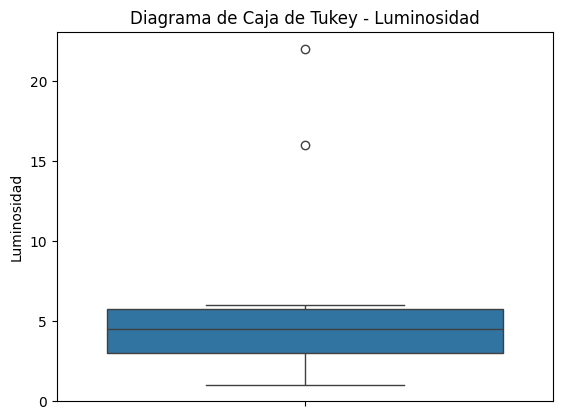

In [36]:
ax = sns.boxplot(data=df_estrellas, y='Luminosidad')
ax.set(title='Diagrama de Caja de Tukey - Luminosidad', ylabel='Luminosidad')
plt.show()

# 5. Ejercicio integrador: Ofertas de trabajo

El archivo **trabajos.xlsx** contiene ejemplos de ofertas de trabajo de una plataforma online. Para poder utilizarlo en un proceso de minería de datos se requiere un **extenso** proceso de limpieza, como con cualquier conjunto de datos recolectados de sistemas existentes. En particular, hay muchos atributos con información codificada como texto, algo muy común en cualquier conjunto de datos.


In [52]:
# HELPER
df_trabajos = pd.read_excel(base_url + "trabajos.xlsx")

In [38]:
df_trabajos.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"



A.  Mire con detenimiento el conjunto de datos, en particular, los valores de los atributos "Job Title" y "Job Description".


In [53]:
df_trabajos[['Job Title', 'Job Description']].head()

,Job Title,Job Description
0,Sr Data Scientist,Description\n\nThe Senior Data Scientist is re...
1,Data Scientist,"Secure our Nation, Ignite your Future\n\nJoin ..."
2,Data Scientist,Overview\n\n\nAnalysis Group is one of the lar...
3,Data Scientist,JOB DESCRIPTION:\n\nDo you have a passion for ...
4,Data Scientist,Data Scientist\nAffinity Solutions / Marketing...



B.  Elimine atributos que no aportan información: : index, Competitors, Company Name



In [54]:
df_trabajos_clean = df_trabajos.drop(columns=['index', 'Competitors', 'Company Name'])
df_trabajos_clean.head()

,Job Title,Salary Estimate,Job Description,Rating,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD)
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD)
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD)
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable



C.  Genere a partir de los existentes los siguientes atributos:

a.  Sueldo mínimo: codificado como número

b.  Sueldo máximo: codificado como número

c.  Sueldo promedio: codificado como número

d.  Ubicación: Del trabajo, codificada como el código del estado de dos letras (por ej, NY o MA), sin la ciudad. Quitar el resto de los atributos de ubicación (Location y Headquarters).

e.  Antigüedad de la compañía, codificada como número, en base a la Fecha de fundación. Quitar la fecha de fundación.

f.  Senior: Si el trabajo es para una persona con mucha experiencia (atributo binario)\ Nota: Para identificar si un trabajo es "Senior", consultar si los atributos "Job Title" o "Job Description" contienen las palabras: "Senior", "Sr", "Sr.", ¿Qué otras palabras se te ocurren para mejorar este atributo?

g.  Junior: si el trabajo es para una persona con poca experiencia (atributo binario).\ Nota: Para identificar si un trabajo es "Junior", consultar si los atributos "Job Title" o "Job Description" contienen las palabras: "Junior" o "Jr". ¿Qué otras palabras se te ocurren para mejorar este atributo?

h.  "Public" y "Private", atributos binarios en base al atributo "Type of ownership". Eliminar ese atributo.

i.  "Estimated size" y "Estimated revenue", en base a "Size" y "Revenue", pero los nuevos atributos deben ser numéricos, y deben corresponder al máximo de los valores que aparecen de forma textual en el atributo. Por ejemplo, si el valor textual es *100 to 500 million (USD)*, el valor numérico debería ser *500.000.000*. En el caso de empresas que no tienen este valor, reemplazar por el promedio.

j.  Los títulos de los trabajos contienen mucha variación y en algunos casos palabras que no contribuyen a la descripción o son muy específicas. Cree 10 atributos binarios con las palabras o frases clave más comunes, como "Data", "Engineer" o "Scientist", y elimine el atributo "Job Title".

k.  Las descripciones de los trabajos están en lenguaje natural y es difícil utilizarlas en un proceso de minería. Identificar 10 habilidades muy ocurrentes que se mencionan en las descripciones y crear un atributo binario por cada una.

l.  Convierta los valores del atributo "Industry" que tengan menos de 20 ocurrencias a "Other".




D.  Elimine los atributos "Job Title" y "Job Description"



E.  Elimine ejemplos con valores faltantes.




F.  Elimine ejemplos repetidos. ¿Por qué es conveniente hacer este paso ahora y no antes?




G.  Experimente y elija 3 gráficos complementarios distintos que le parezca que puedan describir el conjunto de datos de forma visual y resumida.


H. Guardar el resultado

Guarde el dataframe limpio en un archivo llamado `trabajos_limpio.csv`; lo utilizará en las siguientes prácticas.

# 6. Ejercicio integrador: Batallas Pokemon


El archivo **pokemon_attributes.csv** contiene información de distintos Pokemon del juego del mismo nombre. Cada Pokemon tiene varios atributos básicos: puntos de vida (HP), habilidad de ataque, defensa, ataque especial y defensa especial, y velocidad. También se conoce si el Pokemon es legendario, en qué generación fue introducido (8 distintas), su nombre y su identificador. Por último, también tiene hasta 2 tipos característicos, como Agua, Tierra, Aire, etc. El orden de los tipos no es lo importante, y la mayoría de los Pokemon tiene un solo tipo.


Por otro lado, el archivo **pokemon_battles.csv** contiene información sobre las batallas entre Pokemon. Cada batalla tiene un identificador, el nombre del Pokemon que ataca, el nombre del Pokemon que defiende, el resultado de la batalla (ganó el atacante, ganó el defensor)

Para poder realizar una tarea de predicción, que permita qué pokemon gana una batalla en base a sus características, se propone unir estos dos archivos de forma tal de formar uno llamado **pokemon_battles_attributes.csv** que contenga, para cada fila: 

1) Los atributos del pokemon 1
2) Los atributos del pokemon 2
3) Un atributo que indique qué pokemon ganó en una batalla entre ambos

Este archivo debe tener tantas filas como el archivo de batallas, de modo que cada batalla ahora tenga la información de los atributos de los pokemon además del ganador.





In [40]:
#HELPER
df_pokemon_attr = pd.read_csv(base_url + "pokemon_attributes.csv")
df_pokemon_combats = pd.read_csv(base_url + "pokemon_combats.csv")
display(df_pokemon_combats)
display(df_pokemon_attr)

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151
...,...,...,...
49995,707,126,707
49996,589,664,589
49997,303,368,368
49998,109,89,109


,id,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True
